Updated model to modify for normalization N and baseline B.

In [164]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [327]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config, _ = load_default_chrom_configs()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [179]:
#config.alpha = 22

real_deconv1.config.params_dic.update({
 'mu0': 25.95086178727135,
 'delta': 3.5420424946663758,
 'sigma0': 4.574125731433994,
 'sigmav': 0.1041649693276692,
 'lambda': 65.82132480815547,
 'gamma1': 0.7657212868536243,
 'gamma2': 1.,
 'halted': 1.030819214491829e-06,
 'alpha': 0}
)

params = real_deconv1.config.params_dic

mu0 = params['mu0']
gamma1 = params['gamma1']
gamma2 = params['gamma2']

# Trial G2M is 30 minutes long 
g2m_len = 20
g2m_prop_len = g2m_len/params['lambda']
g2m_prop_len

# Update mu0, gamma1, and gamma2 to these fixed lengths and examine the fit
mu0 - g2m_len, gamma1-g2m_prop_len, gamma2-g2m_prop_len

real_deconv1.config.params_dic.update({
 'mu0': mu0 - g2m_len,
 'delta': 3.5420424946663758,
 'sigma0': 4.574125731433994,
 'sigmav': 0.1041649693276692,
 'lambda': 65.82132480815547,
 'gamma1': gamma1-g2m_prop_len,
 'gamma2': gamma2-g2m_prop_len,
 'halted': 1.030819214491829e-06,
 'alpha': 0}
)


In [180]:
real_deconv1.config.update_timepoints()
real_deconv1.config.calculate_H()
real_deconv1.H = real_deconv1.config.H
real_deconv1.config.params_dic

{'mu0': 5.95086178727135,
 'delta': 3.5420424946663758,
 'sigma0': 4.574125731433994,
 'sigmav': 0.1041649693276692,
 'lambda': 65.82132480815547,
 'gamma1': 0.4618683933074595,
 'gamma2': 0.6961471064538352,
 'halted': 1.030819214491829e-06,
 'alpha': 0}

In [182]:
config.get_Hpositions_for_branch('t')

array([22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
       56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
       73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85])

In [184]:
config.get_s_g2m_indices()

30.40078953451119 45.82132480815547


(array([44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
        61, 62]),
 array([63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,
        80, 81, 82, 83, 84, 85]))

In [185]:
real_deconv1.setup_deconvolution(real_deconv1.config)
real_deconv1.iterative_deconvolution_updates(20)

Initializing N using config H.
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
Initializing B using timepoint 0
Iteration 0
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
0/368 - 00:00:00.013
100/368 - 00:00:00.056
200/368 - 00:00:00.097
300/368 - 00:00:00.138
0.007840461919881548
Iteration completed 00:00:00.426, rn=0.007840461919881548
Iteration 1
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
0/368 - 00:00:00.428
100/368 - 00:00:00.465
200/368 - 00:00:00.502
300/368 - 00:00:00.541
0.003790434268371778
Iteration completed 00:00:00.775, rn=0.003790434268371776
Iteration 2
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
0/368 - 00:00:00.776
100/368 - 00:00:00.814
200/368 - 00:00:00.853
300/368 - 00:00:00.890
0.0032761545178822495
Iteration completed 00:00:01.201, rn=0.0032761545178822495
Iteration 3
30.40078953451119 4

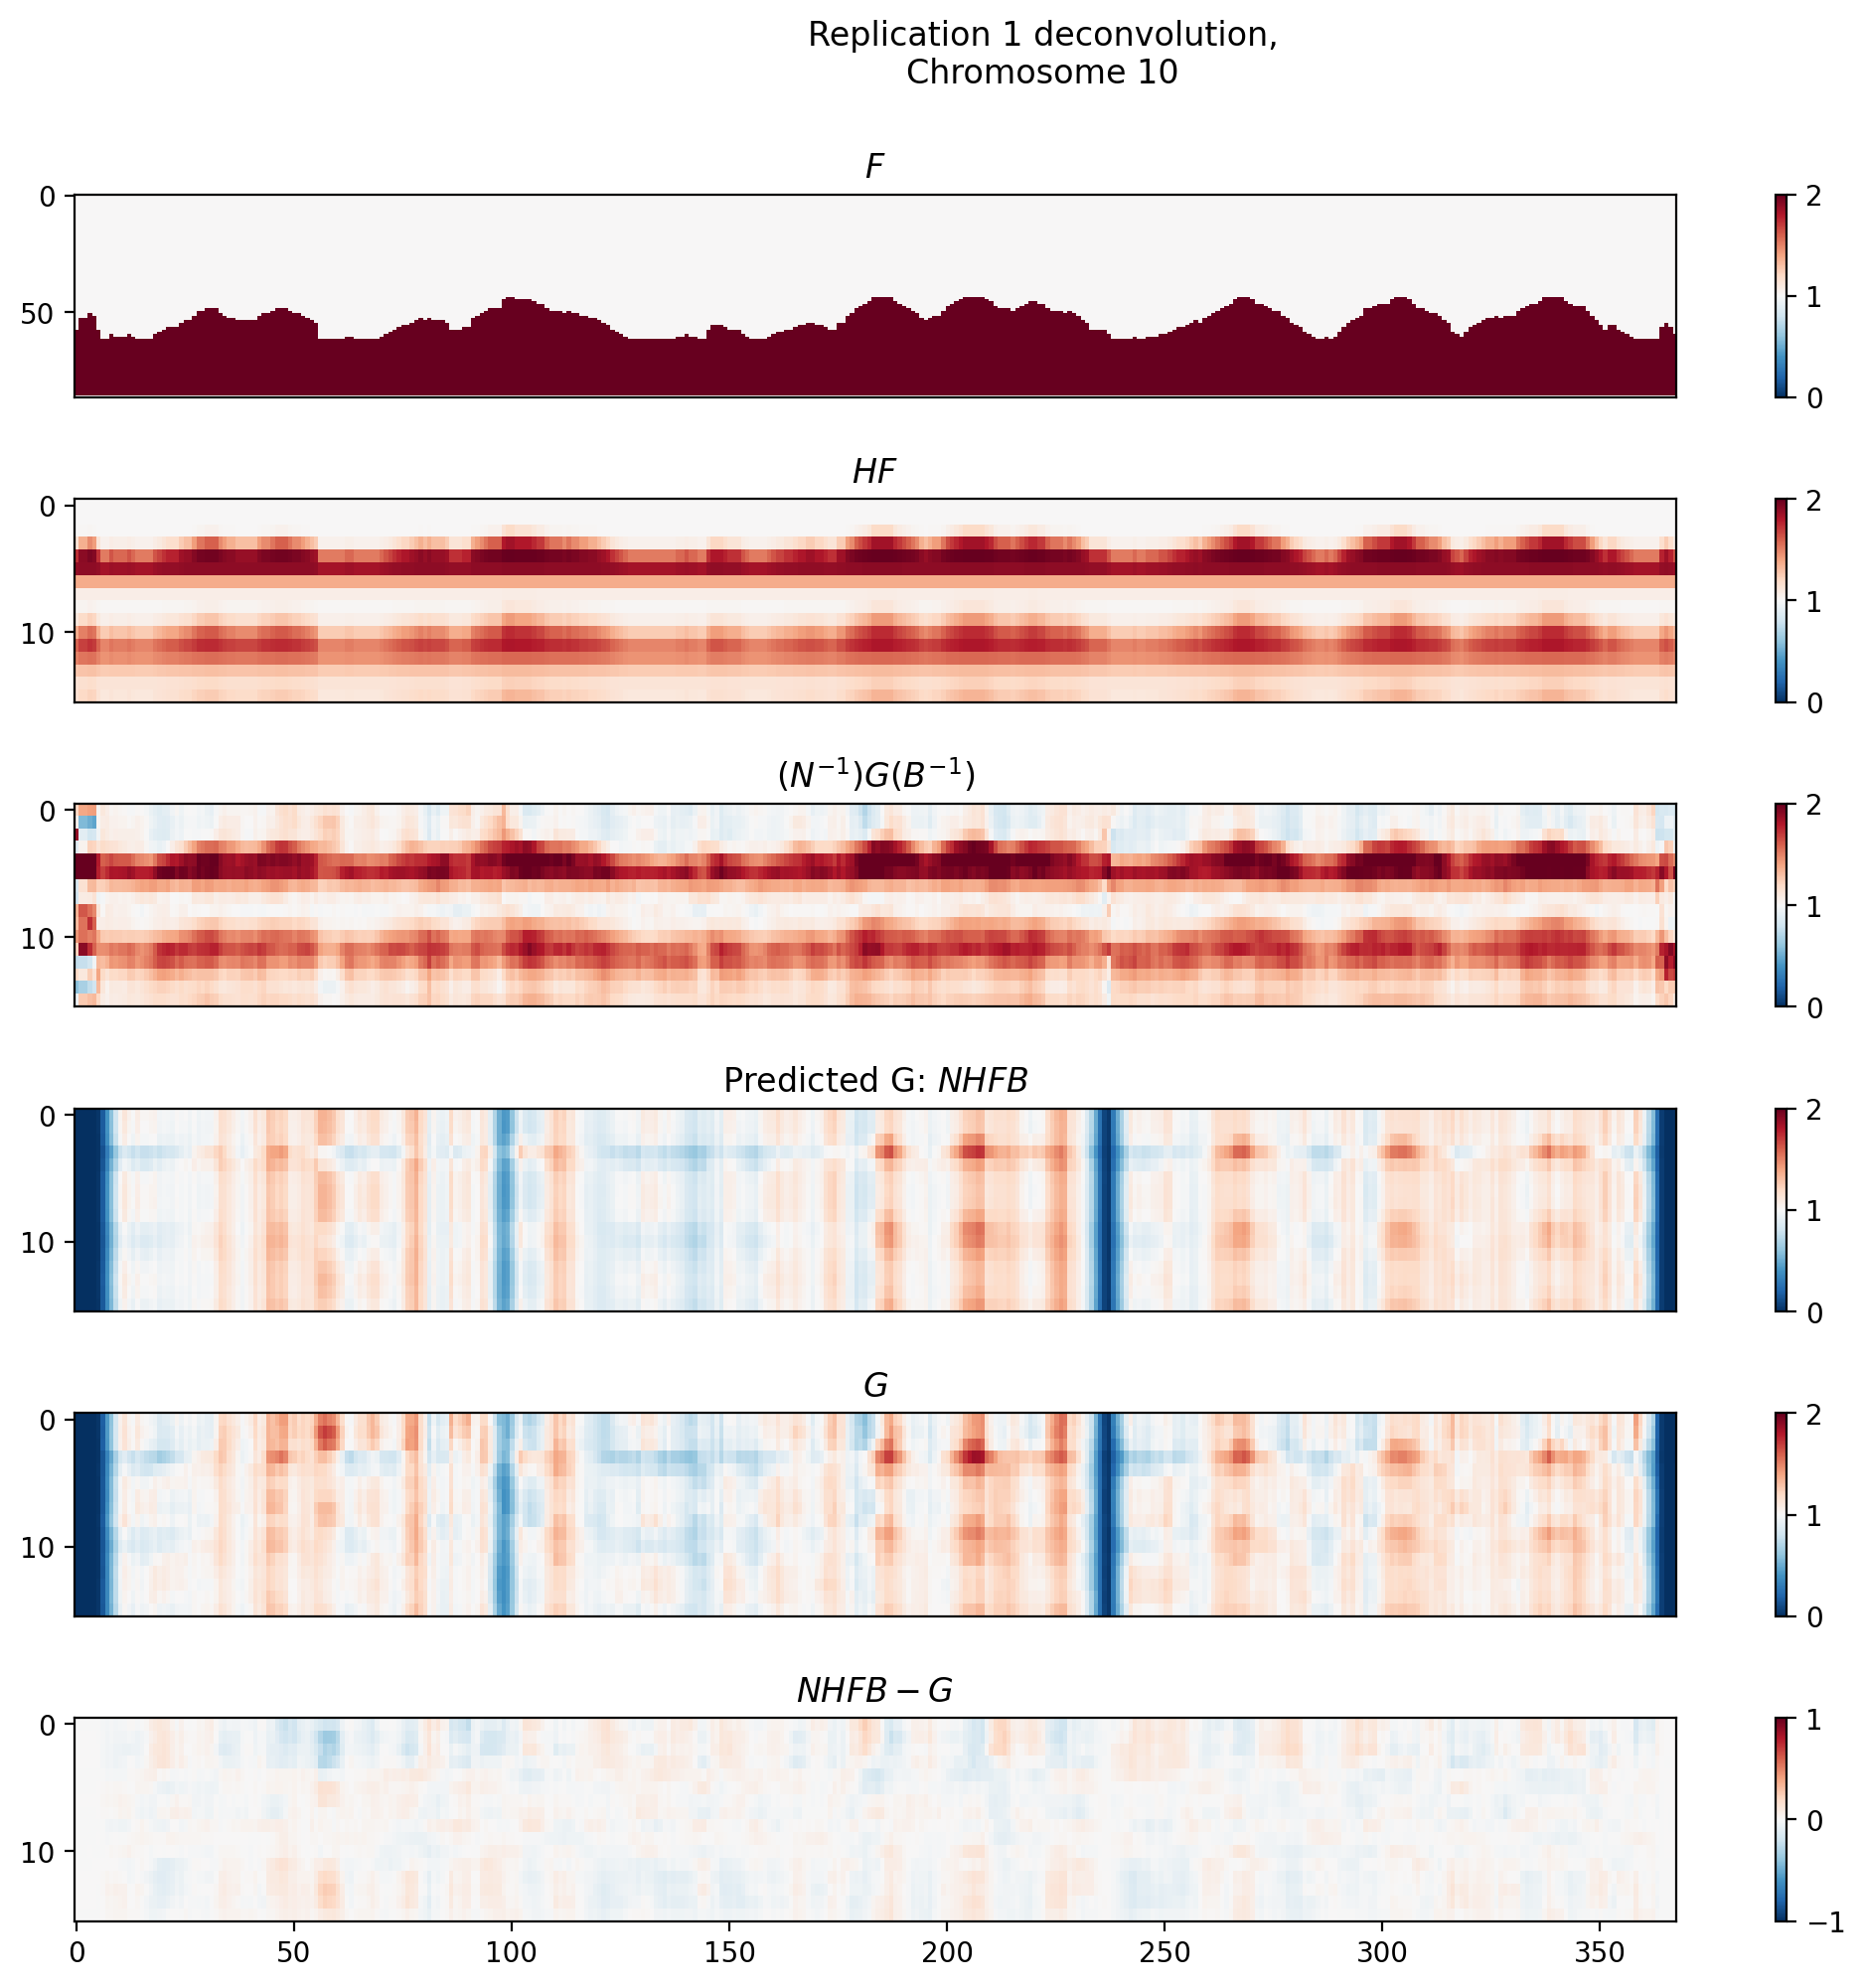

In [186]:
real_deconv1.plot_heatmaps()

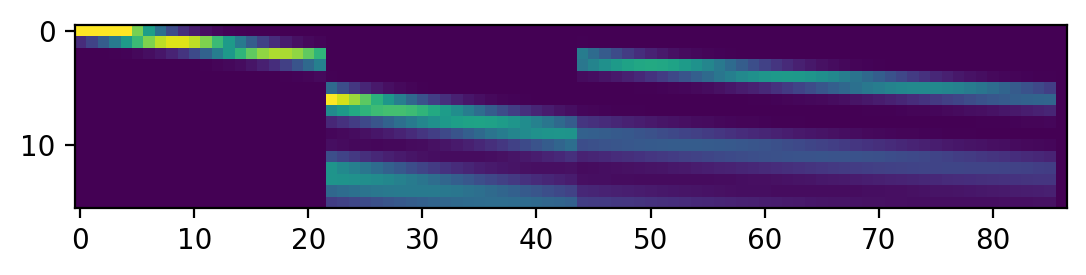

In [187]:
plt.imshow(real_deconv1.config.H, vmax=0.1)


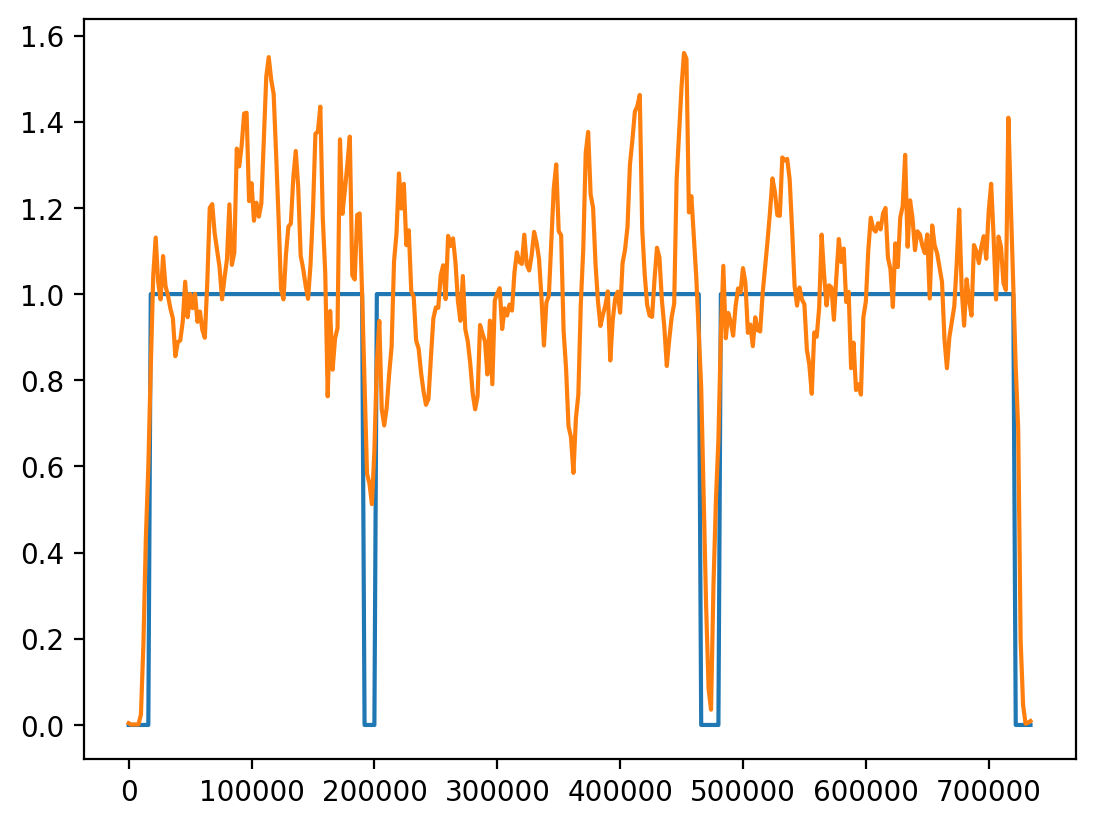

In [191]:
# Let's come up with a strategy to mask out the low coverage regions:

# Goal:
# Use the occupancy data to mask out regions of low occupancy/mappability:
# - Using the initial B occupancy
# - Somehow come up with a strategy to omit the masked out region from the learning of
# the replication profile. A bit mask v (number of windows) long. To be incorporated into the
# loss/rn function
# ----- Refactor note: Place the loss/rn function in one place for both the H optimizer
# and the F replicaiton deconvolver thing.

plt.plot(real_deconv1.selected_threshold_region)
plt.plot(real_deconv1.selected_threshold_region.index, 
         np.diag(real_deconv1.initial_B))


In [344]:
real_deconv1.setup_deconvolution()

Initializing N using config H.
Initializing B using timepoint 0


In [347]:
real_deconv1.iterative_deconvolution_updates(2)

Iteration 0
0/339 - 00:00:00.005
100/339 - 00:00:00.031
200/339 - 00:00:00.054
300/339 - 00:00:00.078
Iteration completed 00:00:00.388, rn=0.008221462892142132
Iteration 1
0/339 - 00:00:00.390
100/339 - 00:00:00.412
200/339 - 00:00:00.436
300/339 - 00:00:00.459
Iteration completed 00:00:00.819, rn=0.005035459204817425


In [ ]:
full_G = real_deconv1.plot_heatmaps()

In [360]:
full_G[0]

0     0.830440
1     0.832252
2     0.825701
3     0.666932
4     0.718410
5     0.774970
6     0.769697
7     0.788520
8     0.811806
9     0.715311
10    0.680441
11    0.731297
12    0.751252
13    0.742946
14    0.747926
15    0.722668
Name: 0, dtype: float64